In [1]:
import numpy as np
import pandas as pd
import json
import sqlite3
import matplotlib.pyplot as plt

In [3]:
## 1. Load Database
conn = sqlite3.connect("../data/thanksgiving_point.db")

households_df = pd.read_sql_query("SELECT * FROM households;",conn)
children_df = pd.read_sql_query("SELECT * FROM children;",conn)
visits_df = pd.read_sql_query("SELECT * FROM visits;",conn)
survey_df = pd.read_sql_query("SELECT * FROM survey_responses;",conn)

In [4]:
## 2. Data Overview
print("Households:", households_df.shape)
print("Children:", children_df.shape)
print("Visits:", visits_df.shape)
print("Survey responses:", survey_df.shape)

print("HOUSEHOLDS")
print(households_df.columns.tolist())
print("\nCHILDREN")
print(children_df.columns.tolist())
print("\nVISITS")
print(visits_df.columns.tolist())
print("\nSURVEY RESPONSES")
print(survey_df.columns.tolist())

Households: (100000, 5)
Children: (244142, 3)
Visits: (308897, 8)
Survey responses: (308897, 11)
HOUSEHOLDS
['household_id', 'family_size', 'adults', 'children_count', 'average_child_age']

CHILDREN
['child_id', 'household_id', 'age']

VISITS
['visit_id', 'household_id', 'visit_date', 'visit_number', 'exhibit', 'crowd_density', 'number_of_programs', 'spending']

SURVEY RESPONSES
['survey_id', 'visit_id', 'household_id', 'satisfaction', 'learning_score', 'curiosity_score', 'confidence_score', 'social_interaction_score', 'return_intent', 'recommend_score', 'comments']


In [5]:
## 3. Checking Data Types
print("\nHOUSEHOLDS")
print(households_df.dtypes)
print("\nCHILDREN")
print(children_df.dtypes)
print("\nVISITS")
print(visits_df.dtypes)
print("\nSURVEY RESPONSES")
print(survey_df.dtypes)



HOUSEHOLDS
household_id          object
family_size            int64
adults                 int64
children_count         int64
average_child_age    float64
dtype: object

CHILDREN
child_id        object
household_id    object
age              int64
dtype: object

VISITS
visit_id               object
household_id           object
visit_date             object
visit_number            int64
exhibit                object
crowd_density         float64
number_of_programs      int64
spending              float64
dtype: object

SURVEY RESPONSES
survey_id                    object
visit_id                     object
household_id                 object
satisfaction                float64
learning_score              float64
curiosity_score             float64
confidence_score            float64
social_interaction_score    float64
return_intent                 int64
recommend_score               int64
comments                     object
dtype: object


In [11]:
## 4. Check Duplicates
print("Households duplicate rows:",households_df.duplicated().sum())
print("Children duplicate rows:",children_df.duplicated().sum())
print("Visits duplicate rows:",visits_df.duplicated().sum())
print("Survey duplicate rows:",survey_df.duplicated().sum())

Households duplicate rows: 0
Children duplicate rows: 0
Visits duplicate rows: 0
Survey duplicate rows: 0


In [14]:
## 5. Household Summary
print("Total households:",households_df["household_id"].nunique())
children_per_household = (children_df.groupby("household_id").size().reset_index(name="number_of_children"))
display(children_per_household.head())
print(children_per_household["number_of_children"].describe())


Total households: 100000


,household_id,number_of_children
0,H00001,2
1,H00002,3
2,H00003,1
3,H00005,3
4,H00007,4


count    93237.000000
mean         2.618510
std          1.067993
min          1.000000
25%          2.000000
50%          3.000000
75%          3.000000
max          5.000000
Name: number_of_children, dtype: float64


Total children: 244142
Unique children: 244142


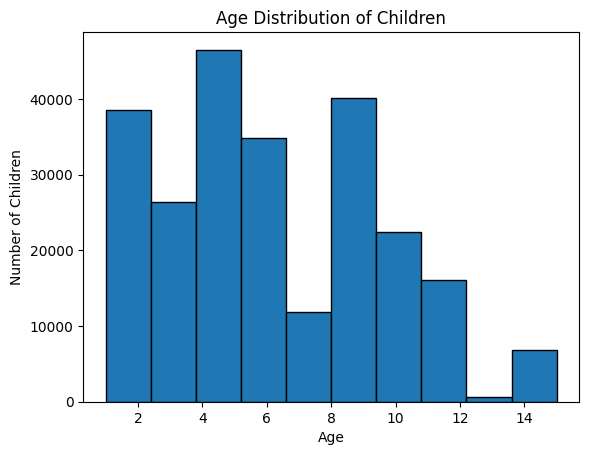

In [17]:
## 6. Explore Children 
print("Total children:", len(children_df))
print("Unique children:",children_df["child_id"].nunique())

children_df["age"].describe()
plt.hist(children_df["age"].dropna(),bins=10,edgecolor="black")

plt.xlabel("Age")
plt.ylabel("Number of Children")
plt.title("Age Distribution of Children")

plt.show()


In [18]:
## 7. Explore Children 
print("Total visits:", len(visits_df))
display(visits_df.head())

visits_df["visit_date"] = pd.to_datetime(visits_df["visit_date"])
visits_per_household = (visits_df.groupby("household_id").size().reset_index(name="visit_count"))

display(visits_per_household.head())
visits_per_household["visit_count"].describe()


Total visits: 308897


,visit_id,household_id,visit_date,visit_number,exhibit,crowd_density,number_of_programs,spending
0,H00001_V1,H00001,2026-01-18,1,Gardens,44.150495,4,39.63
1,H00001_V2,H00001,2026-09-03,2,Gardens,43.584904,3,71.70
2,H00001_V3,H00001,2026-09-06,3,Butterfly Biosphere,19.008313,2,63.19
3,H00001_V4,H00001,2026-07-15,4,Gardens,71.821010,0,66.13
4,H00001_V5,H00001,2026-05-15,5,Dinosaur Museum,35.720337,1,53.73


,household_id,visit_count
0,H00001,7
1,H00002,5
2,H00003,4
3,H00004,1
4,H00005,1


count    100000.000000
mean          3.088970
std           2.325603
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max          12.000000
Name: visit_count, dtype: float64

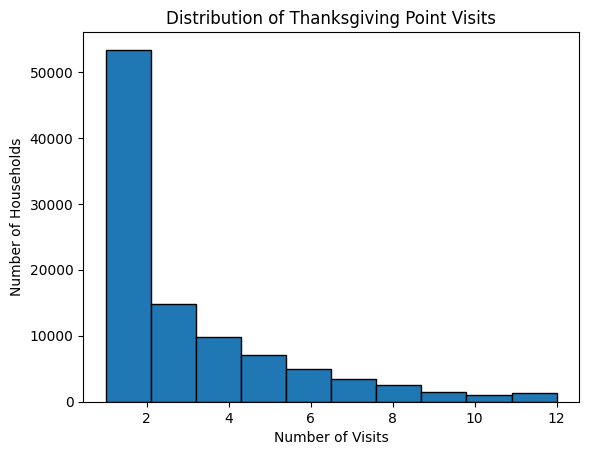

In [19]:
## 8. Visualize Visits Frequency
plt.hist(visits_per_household["visit_count"],bins=10,edgecolor="black")

plt.xlabel("Number of Visits")
plt.ylabel("Number of Households")

plt.title("Distribution of Thanksgiving Point Visits")

plt.show()


In [23]:
## 10. Calculate time between visits
visits_sorted = visits_df.sort_values(["household_id", "visit_date"]).copy()
visits_sorted["days_since_previous_visit"] = (visits_sorted.groupby("household_id")["visit_date"].diff().dt.days)
display(visits_sorted[["household_id","visit_date","days_since_previous_visit" ]].head(20))

visit_gap_summary = (visits_sorted.groupby("household_id")["days_since_previous_visit"].mean().reset_index(name="average_days_between_visits"))
display(visit_gap_summary.head())


,household_id,visit_date,days_since_previous_visit
0,H00001,2026-01-18,NaN
6,H00001,2026-03-17,58.0
4,H00001,2026-05-15,59.0
3,H00001,2026-07-15,61.0
5,H00001,2026-08-16,32.0
1,H00001,2026-09-03,18.0
2,H00001,2026-09-06,3.0
10,H00002,2026-02-22,NaN
11,H00002,2026-03-26,32.0
8,H00002,2026-04-13,18.0


,household_id,average_days_between_visits
0,H00001,38.500000
1,H00002,40.000000
2,H00003,45.666667
3,H00004,NaN
4,H00005,NaN


In [25]:
## 11. House Visit Summary
visit_summary = visits_per_household.merge(visit_gap_summary,on="household_id",how="left")

display(visit_summary.head())
display(visit_summary.describe())


,household_id,visit_count,average_days_between_visits
0,H00001,7,38.500000
1,H00002,5,40.000000
2,H00003,4,45.666667
3,H00004,1,NaN
4,H00005,1,NaN


,visit_count,average_days_between_visits
count,100000.000000,69603.000000
mean,3.088970,60.750755
std,2.325603,44.135451
min,1.000000,0.000000
25%,1.000000,31.000000
50%,2.000000,47.600000
75%,4.000000,76.666667
max,12.000000,259.000000


In [29]:
## 12. Number of surveys per household
surveys_per_household = (survey_df.groupby("household_id").size().reset_index(name="survey_count"))

display(surveys_per_child.head())
surveys_per_child["survey_count"].value_counts().sort_index()

,household_id,survey_count
0,H00001,7
1,H00002,5
2,H00003,4
3,H00004,1
4,H00005,1


survey_count
1     30397
2     22960
3     14879
4      9833
5      7101
6      4962
7      3507
8      2499
9      1493
10     1093
11      886
12      390
Name: count, dtype: int64

In [ ]:
## 13.Merge surveys with visits

